# CML vs BIDS Comparison

Using `bids_validation` package with `CMLBIDSReader`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
import numpy as np
import pandas as pd
import cmlreaders as cml
import matplotlib.pyplot as plt
%matplotlib inline

from cmldask import CMLDask
from dask.distributed import wait, progress

from eeg_validation import (
    EventsPipeline,
    RawSignalPipeline,
    EpochedPipeline,
    MontagePipeline,
)
from eeg_validation.io import load_and_concat
from eeg_validation.plotting import plot_comparison_results

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
import sys
sys.path.append("/home1/zrentala/bidsreader")
from bidsreader import CMLBIDSReader

## 1. Configuration

In [2]:
# ---- Shared settings ----
REL_START = 200      # ms
REL_STOP  = 500     # ms
BUFFER_MS = 500     # ms
tmin = -BUFFER_MS
tmax = REL_STOP + BUFFER_MS

MAX_SUBJECTS = 10
SUBJECTS_TO_EXCLUDE = {"LTP001", "LTP9992", "LTP9993"}

# Set to True to skip sessions whose output CSVs already exist
SKIP_IF_EXISTS = True


---
## 2. Scalp / LTP Comparisons

### 2a. Select subjects & sessions

In [ ]:
ltp_experiments = ["VFFR"]
ltp_bids_root   = "/data/LTP_BIDS/VFFR"
ltp_out_path    = "results/VFFR_results/"

df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ltp_experiments)].copy()
df_exp = df_exp[~df_exp["subject"].isin(SUBJECTS_TO_EXCLUDE)]

dfs = []
for exp in ltp_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ltp = pd.concat(dfs, ignore_index=True)
print(f"LTP jobs: {len(df_ltp)} sessions across {df_ltp['subject'].nunique()} subjects")
df_ltp[["subject", "experiment", "session"]]


LTP jobs: 465 sessions across 57 subjects


,subject,experiment,session
0,LTP229,VFFR,0
1,LTP229,VFFR,1
2,LTP229,VFFR,2
3,LTP229,VFFR,3
4,LTP229,VFFR,4
...,...,...,...
460,LTP439,VFFR,2
461,LTP439,VFFR,3
462,LTP439,VFFR,4
463,LTP440,VFFR,0


### 2b. Run Raw + Epoched EEG comparisons

In [14]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    bids_root = ltp_bids_root

    # --- Raw (scalp: no acquisition) ---
    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Raw  | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Raw  | {sub} | {exp} | {sess}: {e}")

    # --- Epoched (scalp: no acquisition) ---
    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Epoch | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Epoch | {sub} | {exp} | {sess}: {e}")

[SKIP] Raw  | LTP229 | VFFR | 0

[EpochedPipeline] Starting pipeline for LTP229_VFFR_0
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 0
[SKIP] Raw  | LTP229 | VFFR | 1

[EpochedPipeline] Starting pipeline for LTP229_VFFR_1
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 1
[SKIP] Raw  | LTP229 | VFFR | 2

[EpochedPipeline] Starting pipeline for LTP229_VFFR_2
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 2
[SKIP] Raw  | LTP229 | VFFR | 3

[EpochedPipeline] Starting pipeline for LTP229_VFFR_3
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 3
[SKIP] Raw  | LTP229 | VFFR | 4

[EpochedPipeline] Starting pipeline for LTP229_VFFR_4
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 4
[SKIP] Raw  | LTP229 | VFFR | 5

[EpochedPipeline] Starting pipeline for LTP229_VFFR_5
  Skipping: all 4 output files already exist
[SKIP] Epoch | LTP229 | VFFR | 5
[SKIP] Raw

In [4]:
def run_ltp_raw(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = "/data/LTP_BIDS/"
    out_path = ltp_out_path

    try:
        result = RawSignalPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "raw": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_raw, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_raw_results = client.gather(finished)
print(f"Completed {len(ltp_raw_results)} / {len(futures)} jobs")
client.shutdown()

# --- Parallel version of LTP Epoched EEG comparisons using cmldask ---

def run_ltp_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    bids_root = "/data/LTP_BIDS/"
    out_path = ltp_out_path

    try:
        result = EpochedPipeline(
            sub, exp, sess, bids_root, out_path,
            skip_if_exists=True,
            tmin=tmin, tmax=tmax, verbose=True,
        ).run()
    except Exception as e:
        result = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, "epoch": result}

client = CMLDask.new_dask_client_slurm("logs/" + ltp_out_path, "100GB", max_n_jobs=100)
futures = client.map(run_ltp_epoch, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_epoch_results = client.gather(finished)
print(f"Completed {len(ltp_epoch_results)} / {len(futures)} jobs")
client.shutdown()


Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


2026-04-08 17:09:28,516 - distributed.deploy.adaptive_core - INFO - Adaptive stop


Completed 465 / 465 jobs
Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
Completed 465 / 465 jobs


2026-04-08 17:11:38,064 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### 2c. Run Behavioral Events comparison

In [ ]:
for _, row in df_ltp.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}: {result.get('reason')}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


0         23440
1         31922
2        468068
3        646089
4        646183
         ...   
237    10769845
238    10769847
239    10774076
240    10774082
241    10774084
Name: sample, Length: 242, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 0: None
0         26913
1         35692
2         40775
3         44050
4         46917
         ...   
322    11185152
323    11185154
324    11188636
325    11188640
326    11188642
Name: sample, Length: 327, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 1: None
0          1870
1          4027
2          5323
3          5831
4          6755
         ...   
304    10513236
305    10513236
306    10518356
307    10518362
308    10518364
Name: sample, Length: 309, dtype: int64
[DONE] Events | LTP606 | ValueCourier | 2: None
0        17126
1        19110
2        20114
3        20931
4        21477
        ...   
316    9440931
317    9440931
318    9444682
319    9444687
320    9444687
Name: sample, Length: 321, dtype: int64
[DO

In [9]:
# --- Parallel version of LTP Behavioral Events comparison using cmldask ---

def run_ltp_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    try:
        result = EventsPipeline(
            sub, exp, sess, ltp_bids_root, ltp_out_path,
            skip_if_exists=True,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("ltp_events", "9GB", max_n_jobs=100)
futures = client.map(run_ltp_events, df_ltp.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ltp_events_results = client.gather(finished)
print(f"Completed {len(ltp_events_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:34253` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 51618 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34253 instead
  warnings.warn(


Completed 87 / 87 jobs


### 2d. Aggregate LTP results & plot

In [ ]:
ltp_final = "_final/"
os.makedirs(ltp_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False


FILE_CATEGORIES = [
    "df_raw", "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch", "df_epoch_summary", "df_epoch_time",
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ltp_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ltp_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    if not override_csv and os.path.exists(outfile):
        df_old = pd.read_csv(outfile)
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

In [ ]:
# ltp_final = "_final/"
# os.makedirs(ltp_final, exist_ok=True)

# FILE_CATEGORIES = [
#     "df_raw", "df_raw_summary", "df_raw_time",
#     "df_behavior_summary",
#     "df_epoch", "df_epoch_summary", "df_epoch_time",
# ]

# ltp_dfs = {}
# for cat in FILE_CATEGORIES:
#     files = [
#         os.path.join(dp, f)
#         for dp, _, fns in os.walk(ltp_out_path)
#         for f in fns
#         if f.endswith(".csv") and f.startswith(cat + "_")
#     ]
#     if not files:
#         print(f"Skipping {cat} (no files)")
#         continue
#     df_all = load_and_concat(files)
#     ltp_dfs[cat] = df_all
#     outfile = os.path.join(ltp_final, f"{cat}_all.csv")
#     df_all.to_csv(outfile, index=False)
#     print(f"{cat}: {len(files)} files -> {outfile}")


Skipping df_raw (no files)
Skipping df_raw_summary (no files)
Skipping df_raw_time (no files)
df_behavior_summary: 80 files -> VFFR_final/df_behavior_summary_all.csv
Skipping df_epoch (no files)
Skipping df_epoch_summary (no files)
Skipping df_epoch_time (no files)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


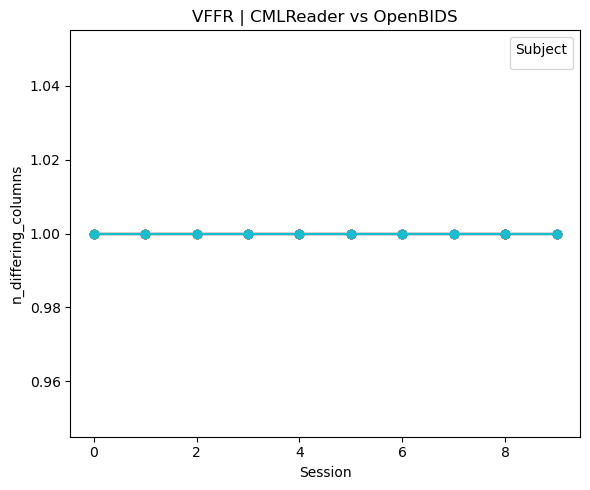

In [ ]:
# --- Raw signal plots ---
if "df_epoch_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_epoch_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_epoch_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_epoch_time"], "mse_time", col_label="MSE Time")

# --- Raw signal plots ---
if "df_raw_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_exact_diff_channels")
    plot_comparison_results(ltp_dfs["df_raw_summary"], "n_close_diff_channels")

# --- Time coord plots ---
if "df_raw_time" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_raw_time"], "mean_abs_time_diff", "std_time_diff", col_label="Mean Abs Time Diff")
    plot_comparison_results(ltp_dfs["df_raw_time"], "mse_time", col_label="MSE Time")

# --- Behavioral plots ---
if "df_behavior_summary" in ltp_dfs:
    plot_comparison_results(ltp_dfs["df_behavior_summary"], "n_differing_columns")


---
## 3. iEEG / RAM Comparisons

### 3a. Select subjects & sessions

In [ ]:
ram_experiments = ["FR1"]
ram_bids_root   = "/data/LTP_BIDS/FR1"
ram_out_path    = "results/FR1_results"
ram_final = "FR1_final_bdf/"
# ram_subjects_to_include = [
#     'R1060M', 'R1061T', 'R1065J', 'R1066P', 'R1092J',
#     'R1108J', 'R1111M', 'R1207J', 'R1226D', 'R1230J',
#     'R1236J', 'R1243T', 'R1247P', 'R1292E', 'R1308T',
#     'R1310J', 'R1328E', 'R1332M', 'R1334T', 'R1337E',
#     'R1341T', 'R1354E', 'R1395M', 'R1542J',
# ]
# ram_subjects_to_include = [
#     'R1001P', 'R1003P', 'R1010J', 'R1018P', 'R1022J', 'R1002P', 'R1006P', 'R1015J', 'R1020J', 'R1023J'
# ]

ram_subjects_nano = [
    'R1010J', 'R1022J', 'R1015J', 'R1020J', 'R1023J'
]


def load_ram_dfs(file_categories, final_dir=ram_final):
    """Load aggregated CSVs from the final directory for each category."""
    dfs = {}
    for cat in file_categories:
        path = os.path.join(final_dir, f"{cat}_all.csv")
        if os.path.exists(path):
            dfs[cat] = pd.read_csv(path)
            print(f"{cat}: loaded {len(dfs[cat])} rows from {path}")
        else:
            print(f"Skipping {cat} (file not found: {path})")
    return dfs


def get_completed_sessions(final_dir=ram_final, summary_files=None):
    """Return set of (subject, session) tuples that appear in ALL *summary* files."""
    import glob
    if summary_files is not None:
        summary_files = [os.path.join(final_dir, f) for f in summary_files]
    else:
        summary_files = sorted(glob.glob(os.path.join(final_dir, "*summary*_all.csv")))
    if not summary_files:
        return set()

    sets = []
    for path in summary_files:
        df = pd.read_csv(path, usecols=["subject", "session"]).dropna(subset=["subject", "session"])
        pairs = set(zip(df["subject"], df["session"].astype(int)))
        sets.append(pairs)
        print(f"  {os.path.basename(path)}: {len(pairs)} (subject, session) pairs")

    completed = sets[0]
    for s in sets[1:]:
        completed &= s
    print(f"  -> {len(completed)} sessions completed across all {len(summary_files)} summary files")
    return completed


# Subjects not in the unit conversion CSV — were previously skipped.
# Include them so they get processed with default unit_scale.
nonconversion_subjects = [
    'R1076D', 'R1092J', 'R1093J', 'R1108J', 'R1124J', 'R1145J', 'R1146E', 'R1147P',
    'R1148P', 'R1150J', 'R1151E', 'R1154D', 'R1156D', 'R1158T', 'R1159P', 'R1161E',
    'R1163T', 'R1164E', 'R1166D', 'R1167M', 'R1168T', 'R1169P', 'R1170J', 'R1171M',
    'R1172E', 'R1173J', 'R1174T', 'R1178P', 'R1184M', 'R1186P', 'R1187P', 'R1189M',
    'R1191J', 'R1193T', 'R1195E', 'R1196N', 'R1200T', 'R1201P', 'R1202M', 'R1203T',
    'R1204T', 'R1207J', 'R1214M', 'R1215M', 'R1216E', 'R1217T', 'R1222M', 'R1223E',
    'R1226D', 'R1228M', 'R1229M', 'R1230J', 'R1231M', 'R1232N', 'R1234D', 'R1236J',
    'R1240T', 'R1241J', 'R1243T', 'R1247P', 'R1250N', 'R1251M', 'R1260D', 'R1264P',
    'R1268T', 'R1274T', 'R1275D', 'R1277J', 'R1281E', 'R1283T', 'R1286J', 'R1288P',
    'R1290M', 'R1292E', 'R1293P', 'R1297T', 'R1298E', 'R1299T', 'R1302M', 'R1304N',
    'R1306E', 'R1308T', 'R1309M', 'R1310J', 'R1313J', 'R1315T', 'R1316T', 'R1317D',
    'R1318N', 'R1320D', 'R1321M', 'R1323T', 'R1324M', 'R1325C', 'R1328E', 'R1329T',
    'R1330D', 'R1331T', 'R1332M', 'R1334T', 'R1336T', 'R1337E', 'R1338T', 'R1339D',
    'R1341T', 'R1342M', 'R1345D', 'R1346T', 'R1347D', 'R1349T', 'R1350D', 'R1351M',
    'R1354E', 'R1355T', 'R1357M', 'R1358T', 'R1361C', 'R1363T', 'R1364C', 'R1367D',
    'R1368T', 'R1373T', 'R1374T', 'R1375C', 'R1376D', 'R1377M', 'R1378T', 'R1379E',
    'R1380D', 'R1381T', 'R1382T', 'R1383J', 'R1384J', 'R1385E', 'R1386T', 'R1387E',
    'R1390M', 'R1391T', 'R1393T', 'R1394E', 'R1395M', 'R1396T', 'R1397D', 'R1398J',
    'R1401J', 'R1402E', 'R1404E', 'R1405E', 'R1406M', 'R1409D', 'R1412M', 'R1413D',
    'R1414E', 'R1415T', 'R1416T', 'R1420T', 'R1421M', 'R1423E', 'R1425D', 'R1427T',
    'R1428T', 'R1431J', 'R1433E', 'R1436J', 'R1438M', 'R1441T', 'R1443D', 'R1446T',
    'R1447M', 'R1448T', 'R1449T', 'R1454M', 'R1457T', 'R1459M', 'R1460M', 'R1461T',
    'R1462M', 'R1463E', 'R1466J', 'R1467M', 'R1542J',
]


# --- Build df_ram, filtering out already-completed sessions ---
df = cml.get_data_index()
df_exp = df[df["experiment"].isin(ram_experiments)].copy()

dfs = []
for exp in ram_experiments:
    df_this = df_exp[df_exp["experiment"] == exp]
    subjects = df_this["subject"].drop_duplicates().sort_values()
    dfs.append(df_this[df_this["subject"].isin(subjects)])

df_ram = pd.concat(dfs, ignore_index=True)
print(f"RAM total: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")

completed = get_completed_sessions(ram_final, summary_files=["df_epoch_summary_all.csv" , "df_raw_summary_all.csv"])
if completed:
    before = len(df_ram)
    df_ram = df_ram[
        ~df_ram.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
    ].reset_index(drop=True)
    print(f"Filtered out {before - len(df_ram)} already-completed sessions")

# Append non-conversion subjects that need rerunning (not yet in completed set)
df_nonconv = df[df["experiment"].isin(ram_experiments) & df["subject"].isin(nonconversion_subjects)].copy()
# Remove any that are already in df_ram or completed
df_nonconv = df_nonconv[
    ~df_nonconv.apply(lambda r: (r["subject"], int(r["session"])) in completed, axis=1)
].reset_index(drop=True)
if not df_nonconv.empty:
    df_ram = pd.concat([df_ram, df_nonconv], ignore_index=True).drop_duplicates(
        subset=["subject", "experiment", "session"]
    ).reset_index(drop=True)
    print(f"Added {len(df_nonconv)} sessions from {df_nonconv['subject'].nunique()} non-conversion subjects")

print(f"RAM jobs: {len(df_ram)} sessions across {df_ram['subject'].nunique()} subjects")
df_ram[["subject", "experiment", "session", "localization", "montage"]].head(20)


RAM total: 587 sessions across 283 subjects
  df_epoch_summary_all.csv: 186 (subject, session) pairs
  df_raw_summary_all.csv: 186 (subject, session) pairs
  -> 186 sessions completed across all 2 summary files
Filtered out 186 already-completed sessions
Added 393 sessions from 181 non-conversion subjects
RAM jobs: 401 sessions across 183 subjects


,subject,experiment,session,localization,montage
0,R1006P,FR1,1,0,0
1,R1076D,FR1,0,0,0
2,R1076D,FR1,1,0,0
3,R1092J,FR1,0,0,2
4,R1092J,FR1,1,0,2
5,R1092J,FR1,2,0,2
6,R1092J,FR1,3,0,3
7,R1093J,FR1,0,0,1
8,R1093J,FR1,1,0,1
9,R1093J,FR1,2,0,1


### 3b. Run Raw + Epoched EEG comparisons (iEEG)

In [4]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        # --- Raw ---
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq, verbose=False,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Raw/{acq}  | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Raw/{acq}  | {sub} | {exp} | {sess}: {e}")
            


        # --- Epoched ---
        try:
            result = EpochedPipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
                tmin=tmin, tmax=tmax, verbose=False,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Epoch/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Epoch/{acq} | {sub} | {exp} | {sess}: {e}")

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Reading 0 ... 1051392  =      0.000 ...  2104.017 secs...
[DONE] Raw/contacts  | R1006P | FR1 | 1
[SKIP] Epoch/contacts | R1006P | FR1 | 1


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_acq-bipolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_acq-bipolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1006P/ses-1/ieeg/sub-R1006P_ses-1_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Reading 0 ... 1051392  =      0.000 ...  2104.017 secs...
[DONE] Raw/pairs  | R1006P | FR1 | 1
[SKIP] Epoch/pairs | R1006P | FR1 | 1


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_acq-monopolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_acq-monopolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Reading 0 ... 2916999  =      0.000 ...  2916.999 secs...
[DONE] Raw/contacts  | R1076D | FR1 | 0
[SKIP] Epoch/contacts | R1076D | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


Extracting EDF parameters from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_acq-bipolar_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_events.tsv.
Reading channel info from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_acq-bipolar_channels.tsv.
Reading electrode coords from /data/LTP_BIDS/FR1/sub-R1076D/ses-0/ieeg/sub-R1076D_ses-0_task-FR1_space-MNI152NLin6ASym_electrodes.tsv.
Reading 0 ... 2916999  =      0.000 ...  2916.999 secs...


KeyboardInterrupt: 

In [8]:
# --- Parallel version of RAM Raw + Epoched EEG comparisons using cmldask ---

def run_ram_raw_epoch(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    # bids_root = "/data/LTP_BIDS/FR1"
    # out_path = "ram_results_unit_convert_cml_2_uV"
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = RawSignalPipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=False,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"raw_{acq}"] = result
        except Exception as e:
            results[f"raw_{acq}"] = {"error": str(e)}

        try:
            result = EpochedPipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=False,
                localization=loc, montage=mon,
                acquisition=acq,
                tmin=tmin, tmax=tmax,
            ).run()
            results[f"epoch_{acq}"] = result
        except Exception as e:
            results[f"epoch_{acq}"] = {"error": str(e)}


    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("logs/" + ram_out_path, "80GB", max_n_jobs=50)
futures = client.map(run_ram_raw_epoch, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_raw_epoch_results = client.gather(finished)
print(f"Completed {len(ram_raw_epoch_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:35407` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 51618 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35407 instead
  warnings.warn(


Completed 401 / 401 jobs


### 3c. Run Behavioral Events comparison (iEEG)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root, ram_out_path,
            skip_if_exists=SKIP_IF_EXISTS,
            localization=loc, montage=mon,
        ).run()
        tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
        print(f"[{tag}] Events | {sub} | {exp} | {sess}")
    except Exception as e:
        print(f"[FAIL] Events | {sub} | {exp} | {sess}: {e}")


In [6]:
# --- Parallel version of RAM Behavioral Events comparison using cmldask ---

def run_ram_events(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    try:
        result = EventsPipeline(
            sub, exp, sess, ram_bids_root,ram_out_path,
            skip_if_exists=True,
            localization=loc, montage=mon,
        ).run()
        return {"subject": sub, "experiment": exp, "session": sess, "result": result}
    except Exception as e:
        return {"subject": sub, "experiment": exp, "session": sess, "error": str(e)}

client = CMLDask.new_dask_client_slurm("logs/ram_events/ram_events", "9GB", max_n_jobs=20)
futures = client.map(run_ram_events, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_events_results = client.gather(finished)
print(f"Completed {len(ram_events_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
Completed 401 / 401 jobs


2026-04-03 17:58:52,048 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### 3d. Run Montage comparison (iEEG only)

In [ ]:
for _, row in df_ram.iterrows():
    sub, exp, sess = row["subject"], row["experiment"], int(row["session"])
    loc = int(row["localization"])
    mon = int(row["montage"])

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root, ram_out_path,
                skip_if_exists=SKIP_IF_EXISTS,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            tag = "SKIP" if isinstance(result, dict) and result.get("skipped") else "DONE"
            print(f"[{tag}] Montage/{acq} | {sub} | {exp} | {sess}")
        except Exception as e:
            print(f"[FAIL] Montage/{acq} | {sub} | {exp} | {sess}: {e}")

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_

[DONE] Montage/contacts | R1060M | FR1 | 0
[DONE] Montage/pairs | R1060M | FR1 | 0
[DONE] Montage/contacts | R1060M | FR1 | 1
[DONE] Montage/pairs | R1060M | FR1 | 1
[DONE] Montage/contacts | R1060M | FR1 | 2
[DONE] Montage/pairs | R1060M | FR1 | 2


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_

[DONE] Montage/contacts | R1060M | FR1 | 3
[DONE] Montage/pairs | R1060M | FR1 | 3
[DONE] Montage/contacts | R1061T | FR1 | 0
[DONE] Montage/pairs | R1061T | FR1 | 0
[DONE] Montage/contacts | R1061T | FR1 | 1


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_

...

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(


[DONE] Montage/contacts | R1111M | FR1 | 3
[DONE] Montage/pairs | R1111M | FR1 | 3
[FAIL] Montage/contacts | R1207J | FR1 | 0: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1207J/ses-0/ieeg/sub-R1207J_ses-0_task-FR1_electrodes.tsv'
[FAIL] Montage/pairs | R1207J | FR1 | 0: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1207J/ses-0/ieeg/sub-R1207J_ses-0_task-FR1_electrodes.tsv'
[FAIL] Montage/contacts | R1207J | FR1 | 1: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1207J/ses-1/ieeg/sub-R1207J_ses-1_task-FR1_electrodes.tsv'
[FAIL] Montage/pairs | R1207J | FR1 | 1: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1207J/ses-1/ieeg/sub-R1207J_ses-1_task-FR1_electrodes.tsv'
[DONE] Montage/contacts | R1226D | FR1 | 0


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_

[DONE] Montage/pairs | R1226D | FR1 | 0
[DONE] Montage/contacts | R1226D | FR1 | 1
[DONE] Montage/pairs | R1226D | FR1 | 1
[FAIL] Montage/contacts | R1230J | FR1 | 0: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1230J/ses-0/ieeg/sub-R1230J_ses-0_task-FR1_electrodes.tsv'
[FAIL] Montage/pairs | R1230J | FR1 | 0: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1230J/ses-0/ieeg/sub-R1230J_ses-0_task-FR1_electrodes.tsv'
[FAIL] Montage/contacts | R1230J | FR1 | 2: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1230J/ses-2/ieeg/sub-R1230J_ses-2_task-FR1_electrodes.tsv'
[FAIL] Montage/pairs | R1230J | FR1 | 2: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1230J/ses-2/ieeg/sub-R1230J_ses-2_task-FR1_electrodes.tsv'
[FAIL] Montage/contacts | R1230J | FR1 | 4: [Errno 2] No such file or directory: '/data/LTP_BIDS/FR1/sub-R1230J/ses-4/ieeg/sub-R1230J_ses-4_task-FR1_electrodes.tsv'
[FAIL] Montage/pairs | R1230J | FR1 | 4: [Errno 2] No such

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/cmlreaders/readers/electrodes.py:241: MissingCoordinatesWarning: Could not load MNI coordinates
  warnings.warn(cmlreaders.warnings.MissingCoordinatesWarning(
/usr/global/miniconda/py310_

In [7]:
# --- Parallel version of RAM Montage comparison using cmldask ---

def run_ram_montage(row_dict):
    sub, exp, sess = row_dict["subject"], row_dict["experiment"], int(row_dict["session"])
    loc = int(row_dict["localization"])
    mon = int(row_dict["montage"])
    results = {}

    for acq in ["contacts", "pairs"]:
        try:
            result = MontagePipeline(
                sub, exp, sess, ram_bids_root,ram_out_path,
                skip_if_exists=True,
                localization=loc, montage=mon,
                acquisition=acq,
            ).run()
            results[f"montage_{acq}"] = result
        except Exception as e:
            results[f"montage_{acq}"] = {"error": str(e)}

    return {"subject": sub, "experiment": exp, "session": sess, **results}

client = CMLDask.new_dask_client_slurm("ram_montage", "9GB", max_n_jobs=100)
futures = client.map(run_ram_montage, df_ram.to_dict("records"))
progress(futures)
wait(futures)

finished = CMLDask.filter_futures(futures)
ram_montage_results = client.gather(finished)
print(f"Completed {len(ram_montage_results)} / {len(futures)} jobs")
client.shutdown()

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.141:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser
Completed 401 / 401 jobs


2026-04-03 17:59:24,766 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### 3e. Aggregate RAM results & plot

In [4]:
os.makedirs(ram_final, exist_ok=True)
ignore_if_csv_exists = False
override_csv = False

FILE_CATEGORIES_RAM = [
     "df_raw_summary", "df_raw_time",
    "df_behavior_summary",
    "df_epoch_summary", "df_epoch_time",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary","df_epoch", "df_raw", 
]

ID_COLS = ["subject", "experiment", "session", "comparison","source_a","source_b","event_type", "acquisition"]

# ram_dfs = {}
for cat in FILE_CATEGORIES_RAM:
    final_csv_name = f"{cat}_all.csv"
    outfile = os.path.join(ram_final, final_csv_name)
    if os.path.exists(outfile) and ignore_if_csv_exists:
        print(f"Skipping {cat} (ignore_if_csv_exists is True and csv is found)")
        if override_csv:
            print("Could not overwrite file since we have ignored the file. You shouldet override_csv to False.")
        continue

    files = [
        os.path.join(dp, f)
        for dp, _, fns in os.walk(ram_out_path)
        for f in fns
        if f.endswith(".csv") and f.startswith(cat + "_")
    ]
    print(files)
    if not files:
        print(f"Skipping {cat} (no files)")
        continue
    df_new = load_and_concat(files)
    # ram_dfs[cat] = df_new

    if not override_csv and os.path.exists(outfile):
        df_old = pd.read_csv(outfile)
        # Only append rows whose keys are not already in the old data
        keys = [k for k in ID_COLS if k in df_old.columns and k in df_new.columns]
        if keys:
            df_new_only = df_new.merge(df_old[keys].drop_duplicates(), on=keys, how="left", indicator=True)
            df_new_only = df_new_only[df_new_only["_merge"] == "left_only"].drop(columns=["_merge"])
            df_all = pd.concat([df_old, df_new_only], ignore_index=True)
        else:
            df_all = pd.concat([df_old, df_new], ignore_index=True)
        print(f"{cat}: kept {len(df_old)} old rows, added {len(df_all) - len(df_old)} new rows")
    else:
        df_all = df_new
        if override_csv:
            print(f"Saving over old {outfile}")

    df_all.to_csv(outfile, index=False)
    print(f"{cat}: {len(files)} files -> {outfile} ({len(df_all)} total rows)")
    del df_all, df_new

['FR1_results/df_raw_summary_R1121M_FR1_4_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_2_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_6_contacts.csv', 'FR1_results/df_raw_summary_R1076D_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_4_pairs.csv', 'FR1_results/df_raw_summary_R1121M_FR1_2_pairs.csv', 'FR1_results/df_raw_summary_R1121M_FR1_3_contacts.csv', 'FR1_results/df_raw_summary_R1146E_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_6_pairs.csv', 'FR1_results/df_raw_summary_R1121M_FR1_1_contacts.csv', 'FR1_results/df_raw_summary_R1092J_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_3_pairs.csv', 'FR1_results/df_raw_summary_R1092J_FR1_2_contacts.csv', 'FR1_results/df_raw_summary_R1108J_FR1_3_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_5_contacts.csv', 'FR1_results/df_raw_summary_R1093J_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1108J_FR1_1_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_5_pairs.csv', 'FR1_r

/tmp/ipykernel_625460/2110695728.py:40: DtypeWarning: Columns (15,16,23,24,25,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_old = pd.read_csv(outfile)


df_epoch: kept 26011836 old rows, added 68601557 new rows
df_epoch: 2928 files -> FR1_final_bdf/df_epoch_all.csv (94613393 total rows)
['FR1_results/df_raw_R1121M_FR1_4_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_4_contacts.csv', 'FR1_results/df_raw_R1121M_FR1_2_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_2_contacts.csv', 'FR1_results/df_raw_R1121M_FR1_6_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_6_contacts.csv', 'FR1_results/df_raw_R1076D_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1076D_FR1_0_contacts.csv', 'FR1_results/df_raw_R1121M_FR1_4_pairs.csv', 'FR1_results/df_raw_summary_R1121M_FR1_4_pairs.csv', 'FR1_results/df_raw_R1121M_FR1_2_pairs.csv', 'FR1_results/df_raw_summary_R1121M_FR1_2_pairs.csv', 'FR1_results/df_raw_R1121M_FR1_3_contacts.csv', 'FR1_results/df_raw_summary_R1121M_FR1_3_contacts.csv', 'FR1_results/df_raw_R1146E_FR1_0_contacts.csv', 'FR1_results/df_raw_summary_R1146E_FR1_0_contacts.csv', 'FR1_results/df_raw_R1121M_FR1_6_pairs.csv',

In [5]:
FILE_CATEGORIES_RAM = [
    "df_behavior_summary",
    "df_contacts_summary", "df_contacts_column_summary", "df_contacts_mismatches",
    "df_pairs_summary", "df_pairs_column_summary", "df_pairs_mismatches",
    "df_montage_summary"
]

ram_dfs = load_ram_dfs(FILE_CATEGORIES_RAM)


df_behavior_summary: loaded 552 rows from FR1_final_bdf/df_behavior_summary_all.csv
df_contacts_summary: loaded 546 rows from FR1_final_bdf/df_contacts_summary_all.csv
df_contacts_column_summary: loaded 4404 rows from FR1_final_bdf/df_contacts_column_summary_all.csv
df_contacts_mismatches: loaded 10616 rows from FR1_final_bdf/df_contacts_mismatches_all.csv
df_pairs_summary: loaded 538 rows from FR1_final_bdf/df_pairs_summary_all.csv
df_pairs_column_summary: loaded 2708 rows from FR1_final_bdf/df_pairs_column_summary_all.csv
df_pairs_mismatches: loaded 21689 rows from FR1_final_bdf/df_pairs_mismatches_all.csv
df_montage_summary: loaded 1084 rows from FR1_final_bdf/df_montage_summary_all.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


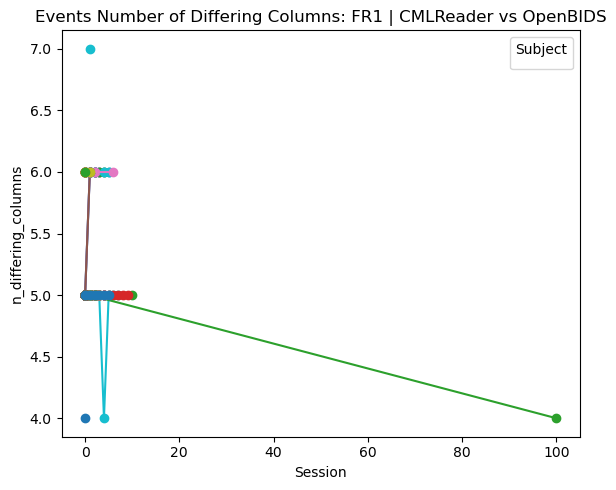

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


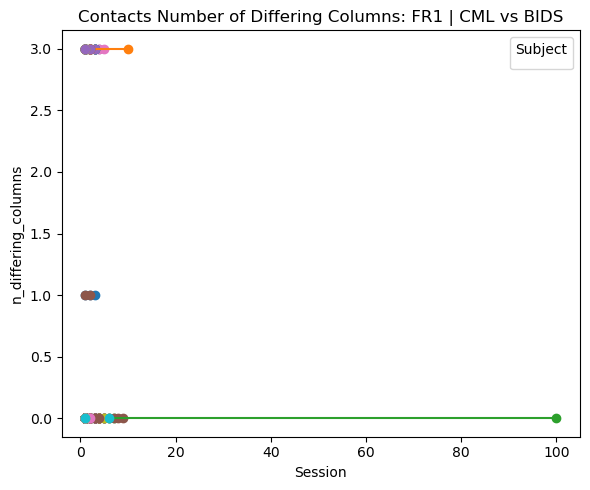

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


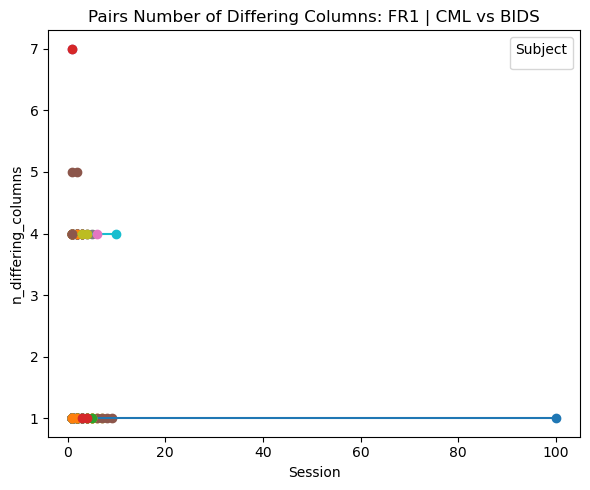

In [6]:
# --- Behavioral plots ---
if "df_behavior_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_behavior_summary"], "n_differing_columns", title="Events Number of Differing Columns")

if "df_contacts_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_contacts_summary"], "n_differing_columns", title="Contacts Number of Differing Columns")

if "df_pairs_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_pairs_summary"], "n_differing_columns", title="Pairs Number of Differing Columns")

del ram_dfs

In [7]:
FILE_CATEGORIES_RAM = [
    "df_epoch_summary", "df_epoch_time",
]

ram_dfs = load_ram_dfs(FILE_CATEGORIES_RAM)


df_epoch_summary: loaded 988 rows from FR1_final_bdf/df_epoch_summary_all.csv
df_epoch_time: loaded 7241 rows from FR1_final_bdf/df_epoch_time_all.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


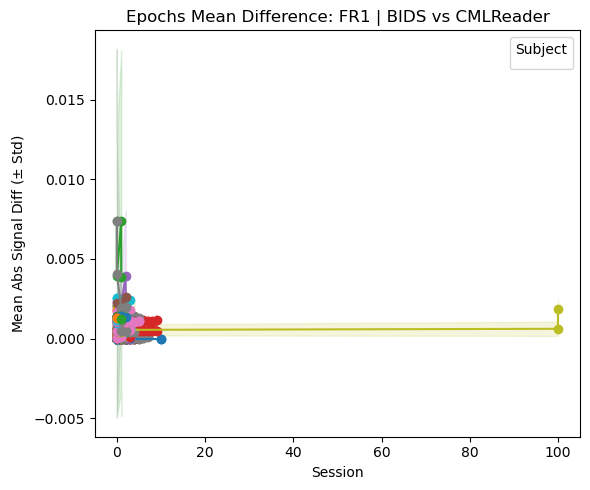

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


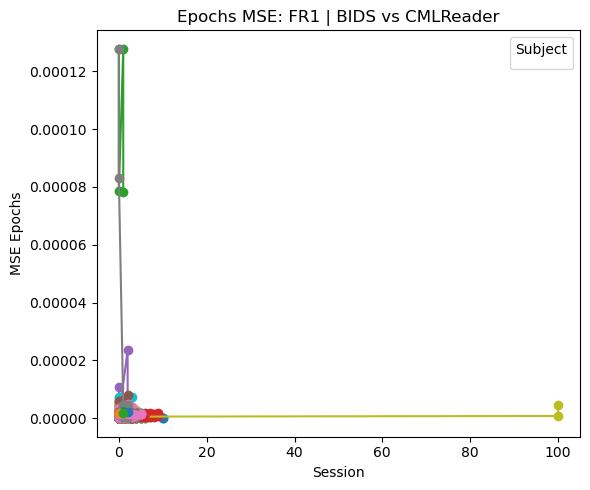

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


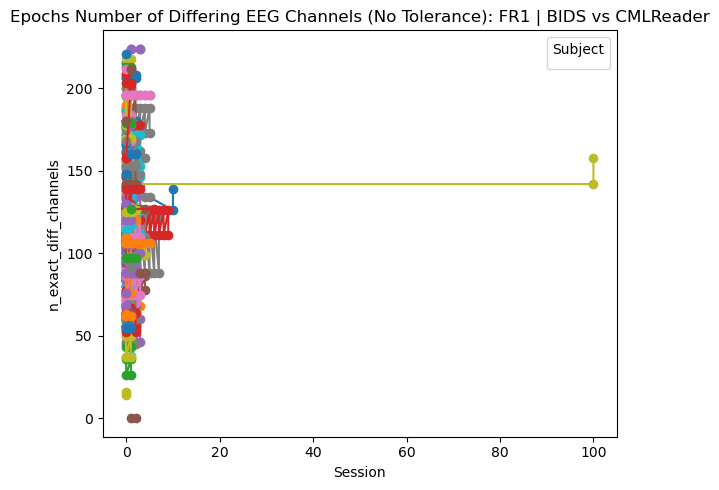

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


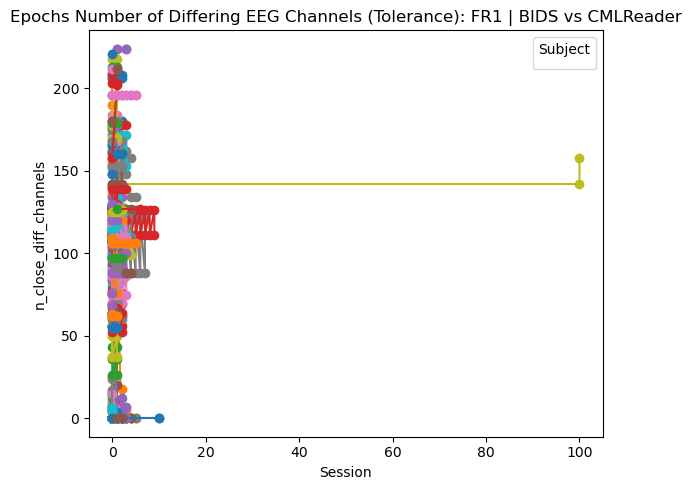

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


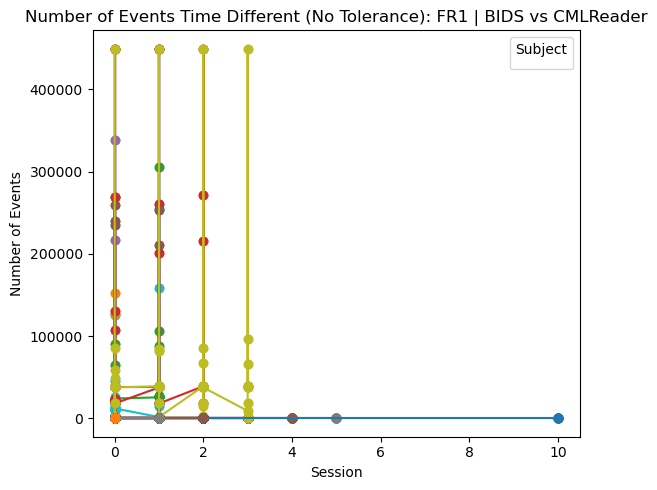

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


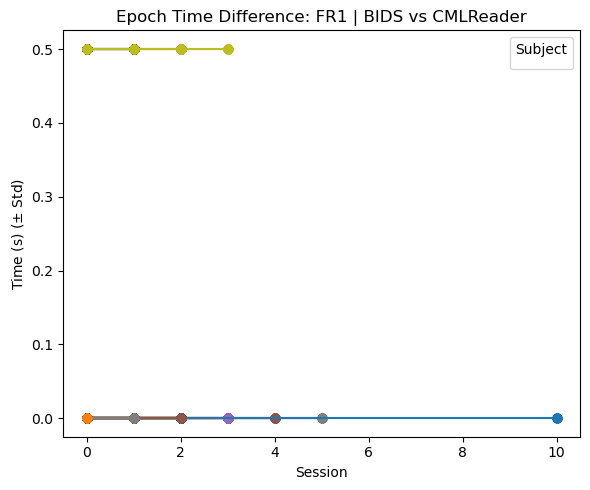

In [8]:
# --- Helper: if summary has per-event rows, aggregate to one row per (subject, session, acquisition) ---
def aggregate_epoch_summary(df):
    """Keep only 'ALL' rows if present, otherwise average over event types."""
    if "event_type" in df.columns and "ALL" in df["event_type"].values:
        return df[df["event_type"] == "ALL"].copy()
    # Fallback: average numeric columns, keep first of non-numeric
    group_cols = ["subject", "experiment", "session", "comparison", "source_a", "source_b"]
    if "acquisition" in df.columns:
        group_cols.append("acquisition")
    group_cols = [c for c in group_cols if c in df.columns]
    return df.groupby(group_cols, as_index=False).mean(numeric_only=True)
# ram_dfs = aggregate_epoch_summary(ram_dfs[])
# --- Raw signal plots ---
if "df_epoch_summary" in ram_dfs:
    epoch_summary = aggregate_epoch_summary(ram_dfs["df_epoch_summary"])
    plot_comparison_results(epoch_summary, "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Epochs Mean Difference")
    plot_comparison_results(epoch_summary, "mse", col_label="MSE Epochs", title="Epochs MSE")
    plot_comparison_results(epoch_summary, "n_exact_diff_channels", title="Epochs Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(epoch_summary, "n_close_diff_channels", title="Epochs Number of Differing EEG Channels (Tolerance)")

if "df_epoch_time" in ram_dfs:
    plot_comparison_results(ram_dfs["df_epoch_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Time Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_epoch_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Epoch Time Difference")

In [9]:
FILE_CATEGORIES_RAM = [
    "df_raw_summary", "df_raw_time",
]

ram_dfs = load_ram_dfs(FILE_CATEGORIES_RAM)


df_raw_summary: loaded 992 rows from FR1_final_bdf/df_raw_summary_all.csv
df_raw_time: loaded 629 rows from FR1_final_bdf/df_raw_time_all.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


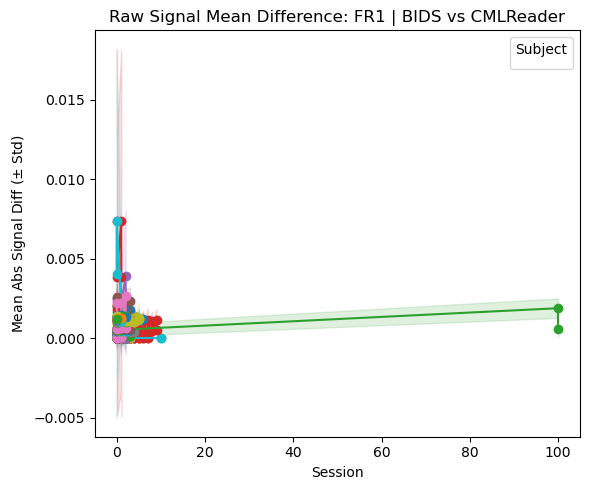

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


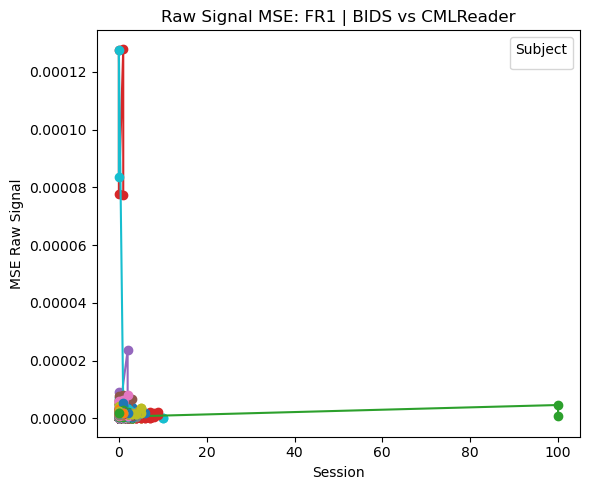

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


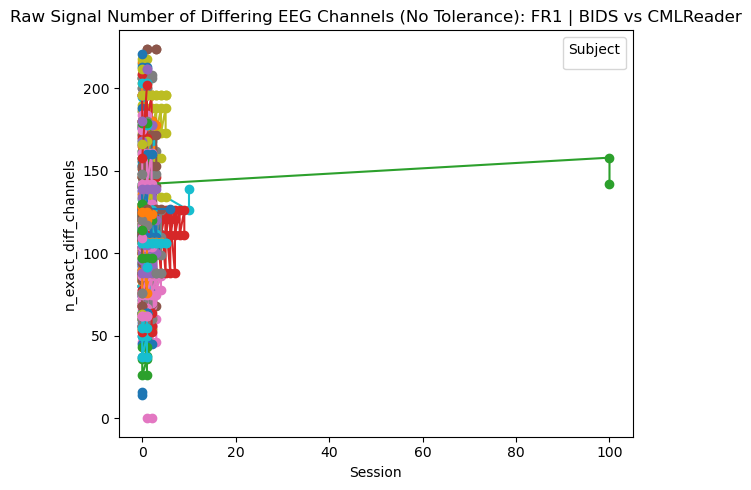

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


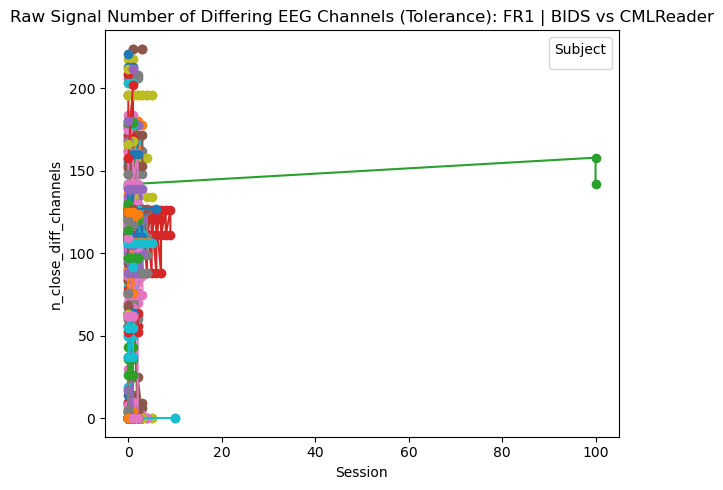

In [10]:
if "df_raw_summary" in ram_dfs:
    plot_comparison_results(ram_dfs["df_raw_summary"], "mean_abs_diff", "std_diff", col_label="Mean Abs Signal Diff", title="Raw Signal Mean Difference")
    plot_comparison_results(ram_dfs["df_raw_summary"], "mse", col_label="MSE Raw Signal", title="Raw Signal MSE")
    plot_comparison_results(ram_dfs["df_raw_summary"], "n_exact_diff_channels", title="Raw Signal Number of Differing EEG Channels (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_summary"], "n_close_diff_channels", title="Raw Signal Number of Differing EEG Channels (Tolerance)")
    
if "df_epoch_time" in ram_dfs:
    # plot_comparison_results(ram_dfs["df_raw_time"], "n_close_time_diff", col_label="Number of Events", title="Number of Events Different (No Tolerance)")
    plot_comparison_results(ram_dfs["df_raw_time"], "mean_abs_time_diff","std_time_diff", col_label="Time (s)", title="Raw Time Difference")